<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Overall Goal

Using the *initial data*, the notebook addresses two related but fundamentally different questions:

1. **PCA:** Which directions explain the greatest amount of variation in the input data?
2. **GPR:** Which input variables actually matter for predicting the output?

The key distinction is that these are **not the same question**.

* **PCA is unsupervised:** It considers only the variation and structure within the input variables, (X), without considering the target (y).
* **GPR is supervised:** It learns the relationship between the inputs, (X), and the target output, (y), allowing it to identify variables that are important for prediction.

The notebook ultimately demonstrates an important point: **a variable can account for a large proportion of the variance in the input data while contributing relatively little to predicting the output**.

The notebook contains:

- PCA / Scree plots
- PCA biplots
- PCA loading heatmaps
- Gaussian Process Regression
- Comparison: PCA vs GPR

# Findings

This notebook investigates **F1–F8** using two complementary approaches. First, **PCA** is used to understand the structure and dimensionality of the input data. Then, an **anisotropic RBF Gaussian Process (GPR)** is used to model the output and estimate the influence of individual input variables.

The analysis ultimately shows that **PCA-based importance and predictive importance can be substantially different**.

The notebook's central conclusion is:

> **High variance does not necessarily mean high predictive importance.**

Therefore, the notebook argues that:

**PCA-based variance reduction should not simply replace supervised feature selection using GPR/ARD.**


| Function | Archetype | Evidence from initial-data-pca-gpr-rbf.ipynb |
|---|---|:---|
| **F1** | `hairline_spike` | Output is basically flat (mean −0.0004, std 0.0011) except one narrow vertical stripe in the surface plot around `Input_1 ≈ 0.65`; correlations near zero (−0.14/−0.17); GP train R² = 0.036 — a smooth kernel can't even fit the training data, classic needle signature. |
| **F2** | `rising_edge` | Strong positive correlation on both inputs (0.75, 0.39), PC1 alone explains 72% of input variance, and the surface is a clean monotone ramp climbing toward a high band near the right edge of the domain. |
| **F3** | `corner_lock` | Train R² = 1.0 but CV R² = −1.2 (severe overfit on 15 points); the "best found" trajectory jumps once then goes perfectly flat for 12 more iterations; EI surface is one smooth concentric bowl in a corner — it was essentially located immediately, just not generalizable from so few points. |
| **F4** | `hidden_bowl` | Per-dimension scatter looks like pure noise, but a degree-2 polynomial gets CV R² = 0.98 — that's the tell of a genuinely smooth single-peak/bowl shape in 4D that just doesn't show up in 1D marginal plots or linear correlations. |
| **F5** | `edge_gradient` | GP mean surface is a smooth one-directional gradient (≈705 → 1065); EI collapses onto a single narrow band near the top edge of one dimension; also has the extreme max (1088.9) sitting right at that edge. |
| **F6** | `noisy_ceiling` | The evaluation trace is a noisy zig-zag with no trend; the very first sample already hit the run's best value (−0.71), and 19 later, wildly scattered samples never beat it — a ceiling reached by chance, not structure. |
| **F7** | `ghost_spike` | Long noisy low-amplitude baseline (0–0.6) punctured by one isolated spike (1.37) that's never approached again — same signature as F1, just noisier and higher-dimensional. |
| **F8** | `deep_lock` | Raw outputs swing noisily (5.6–9.6), but an 8D anisotropic GP fits it almost perfectly (CV R² = 0.996), and the max found in the initial 40 samples is never beaten — the surrogate has effectively already solved it from the initial batch alone. |

| Function | Archetype | Evidence from initial-data-pca-gpr-rbf.ipynb |
|---|---|:---|
| **F1** | `hairline_spike` | The outlier is a razor-thin stripe against a near-zero baseline — "hairline" captures how narrow it is in only 2D. |
| **F2** | `rising_edge` | Clean monotone ramp toward a high band near the domain's edge. |
| **F3** | `corner_lock` | The optimum sits in a smooth bowl tucked in one corner of the input space, and the search locks onto it almost instantly. |
| **F4** | `hidden_bowl` | A smooth single-peak shape that's invisible in 1D/linear views and only emerges under a nonlinear fit. |
| **F5** | `edge_surge` | Same ramp-to-boundary behaviour as F2, but with a much sharper, larger-magnitude surge near the edge (the 1088.9 outlier). |
| **F6** | `noise_ceiling` | Best value is hit almost by chance on the first sample; everything after is noisy scatter below that ceiling. |
| **F7** | `ghost_spike` | Same spike signature as F1, but higher-dimensional and noisier — the spike is harder to "see," more like a ghost in the data. |
| **F8** | `deep_lock` | Same early-converge behaviour as F3, but the surrogate locks onto it with much higher confidence (CV R² = 0.996) despite 8 dimensions — a "deeper," more robust lock. |

# Scree Cumulative Variance Functions (F1-F8)

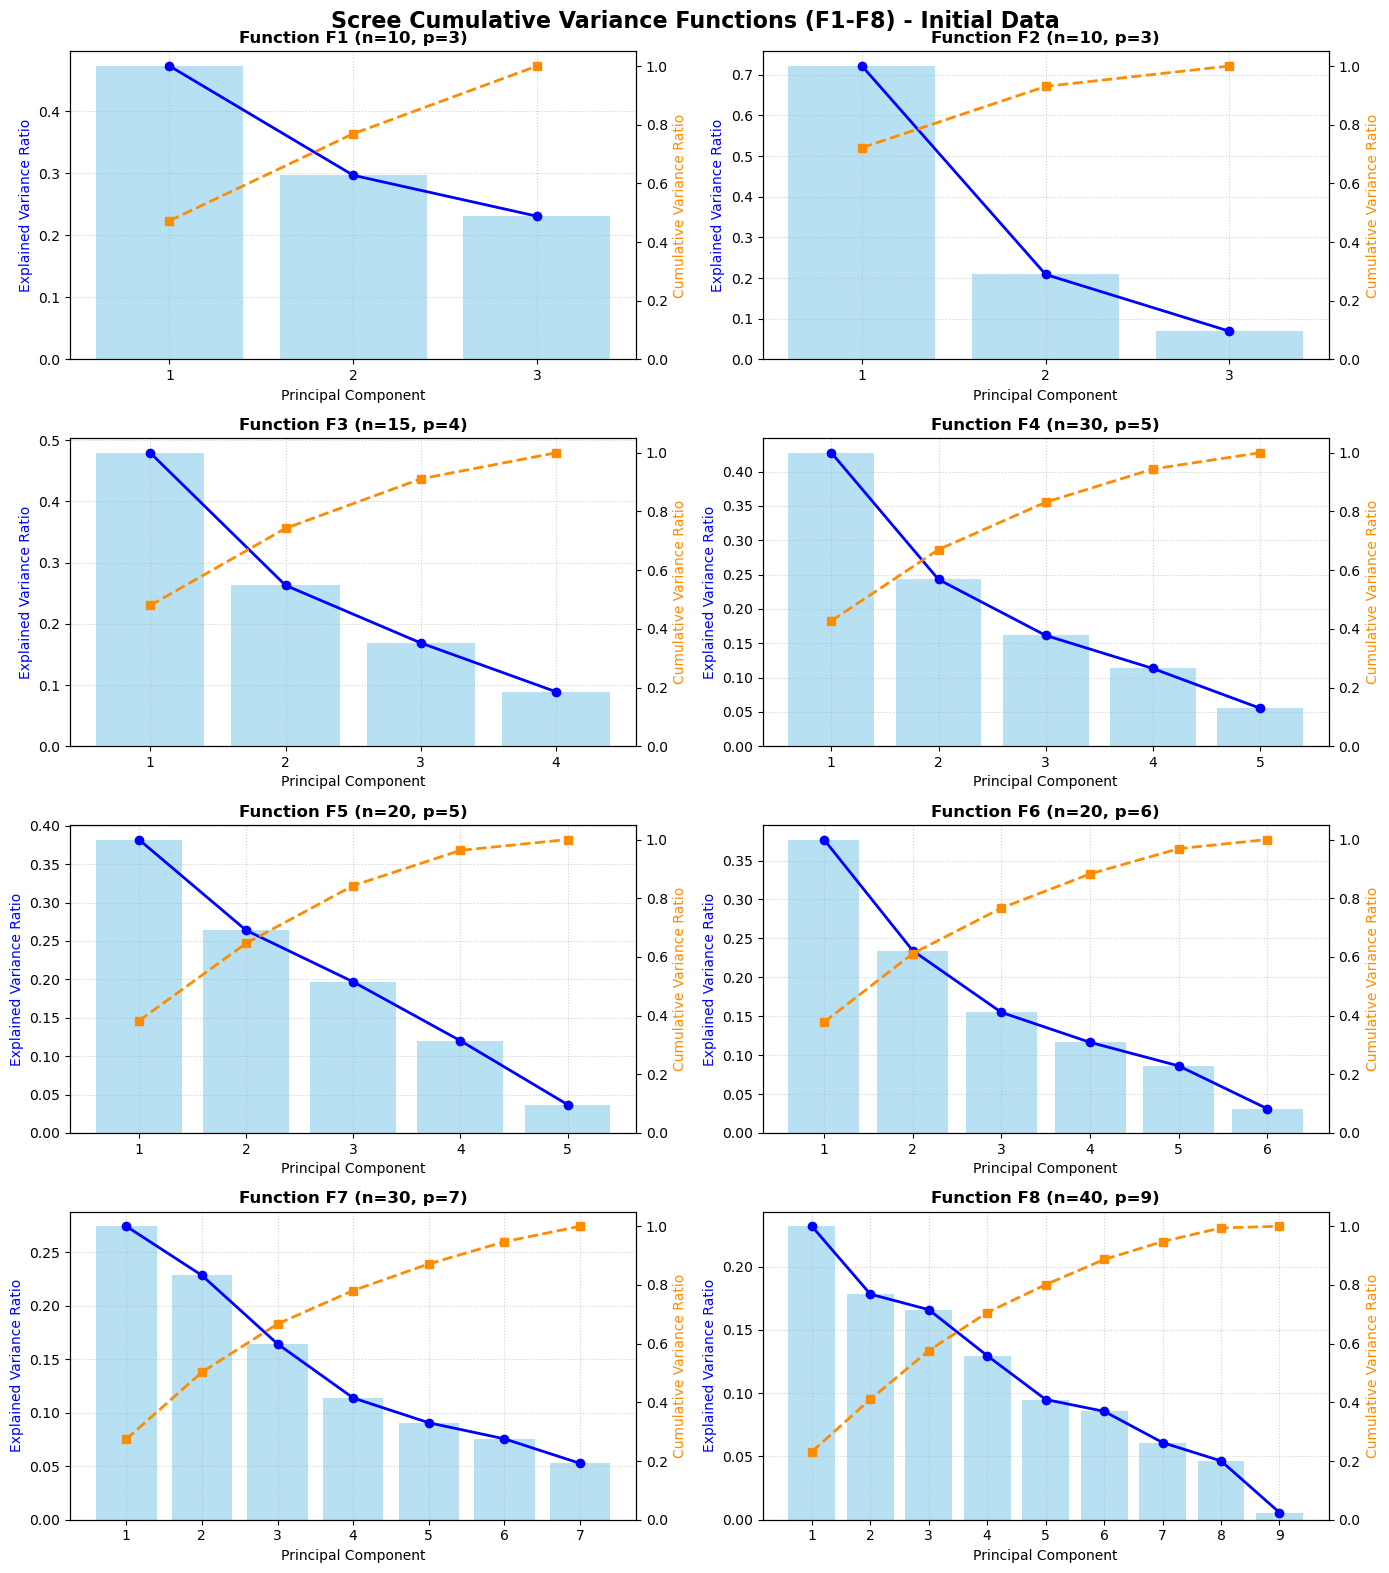

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

filepath = 'initial_data/CapstoneFunction_from_Numpy.xlsx'
xls = pd.ExcelFile(filepath)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

pca_results = {}

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(filepath, sheet_name=sheet)
    
    # Standardize data across all columns (inputs + output)
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    
    pca = PCA()
    pca.fit(df_scaled)
    
    exp_var = pca.explained_variance_ratio_
    cum_var = np.cumsum(exp_var)
    
    pca_results[sheet] = {
        'exp_var': exp_var,
        'cum_var': cum_var,
        'n_components': len(exp_var)
    }
    
    ax = axes[idx]
    components = np.arange(1, len(exp_var) + 1)
    
    # Scree line / bar
    ax.bar(components, exp_var, alpha=0.6, color='skyblue', label='Individual Variance')
    ax.plot(components, exp_var, marker='o', color='blue', linewidth=2, label='Scree Line')
    
    # Cumulative line
    ax2 = ax.twinx()
    ax2.plot(components, cum_var, marker='s', color='darkorange', linewidth=2, linestyle='--', label='Cumulative Variance')
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('Cumulative Variance Ratio', color='darkorange')
    
    ax.set_title(f'Function {sheet} (n={len(df)}, p={df.shape[1]})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance Ratio', color='blue')
    ax.set_xticks(components)
    ax.grid(True, linestyle=':', alpha=0.6)

# Main Title
plt.suptitle('Scree Cumulative Variance Functions (F1-F8) - Initial Data', fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
# plt.savefig('scree_cumulative_variance_all_functions.png', dpi=300, bbox_inches='tight')
plt.show()

Here is the table in **plain text**:

| Function | Variables (p) | Samples (n) | PC1 Explained | PC2 Explained | PC3 Explained | PCs for ≥80% Cumulative Var |
| -------- | ------------: | ----------: | ------------: | ------------: | ------------: | --------------------------: |
| F1       |             3 |          10 |        47.26% |        29.66% |        23.07% |             3 PCs (100.00%) |
| F2       |             3 |          10 |        72.16% |        20.89% |         6.95% |              2 PCs (93.05%) |
| F3       |             4 |          15 |        47.96% |        26.29% |        16.87% |              3 PCs (91.11%) |
| F4       |             5 |          30 |        42.73% |        24.28% |        16.14% |              3 PCs (83.14%) |
| F5       |             5 |          20 |        38.21% |        26.40% |        19.68% |              3 PCs (84.29%) |
| F6       |             6 |          20 |        37.71% |        23.43% |        15.49% |              4 PCs (88.28%) |
| F7       |             7 |          30 |        27.44% |        22.84% |        16.44% |              5 PCs (87.17%) |
| F8       |             9 |          40 |        23.20% |        17.83% |        16.61% |              5 PCs (80.11%) |


# PC1 vs PC2 Scatter Plots Across All Functions (F1 - F8) 

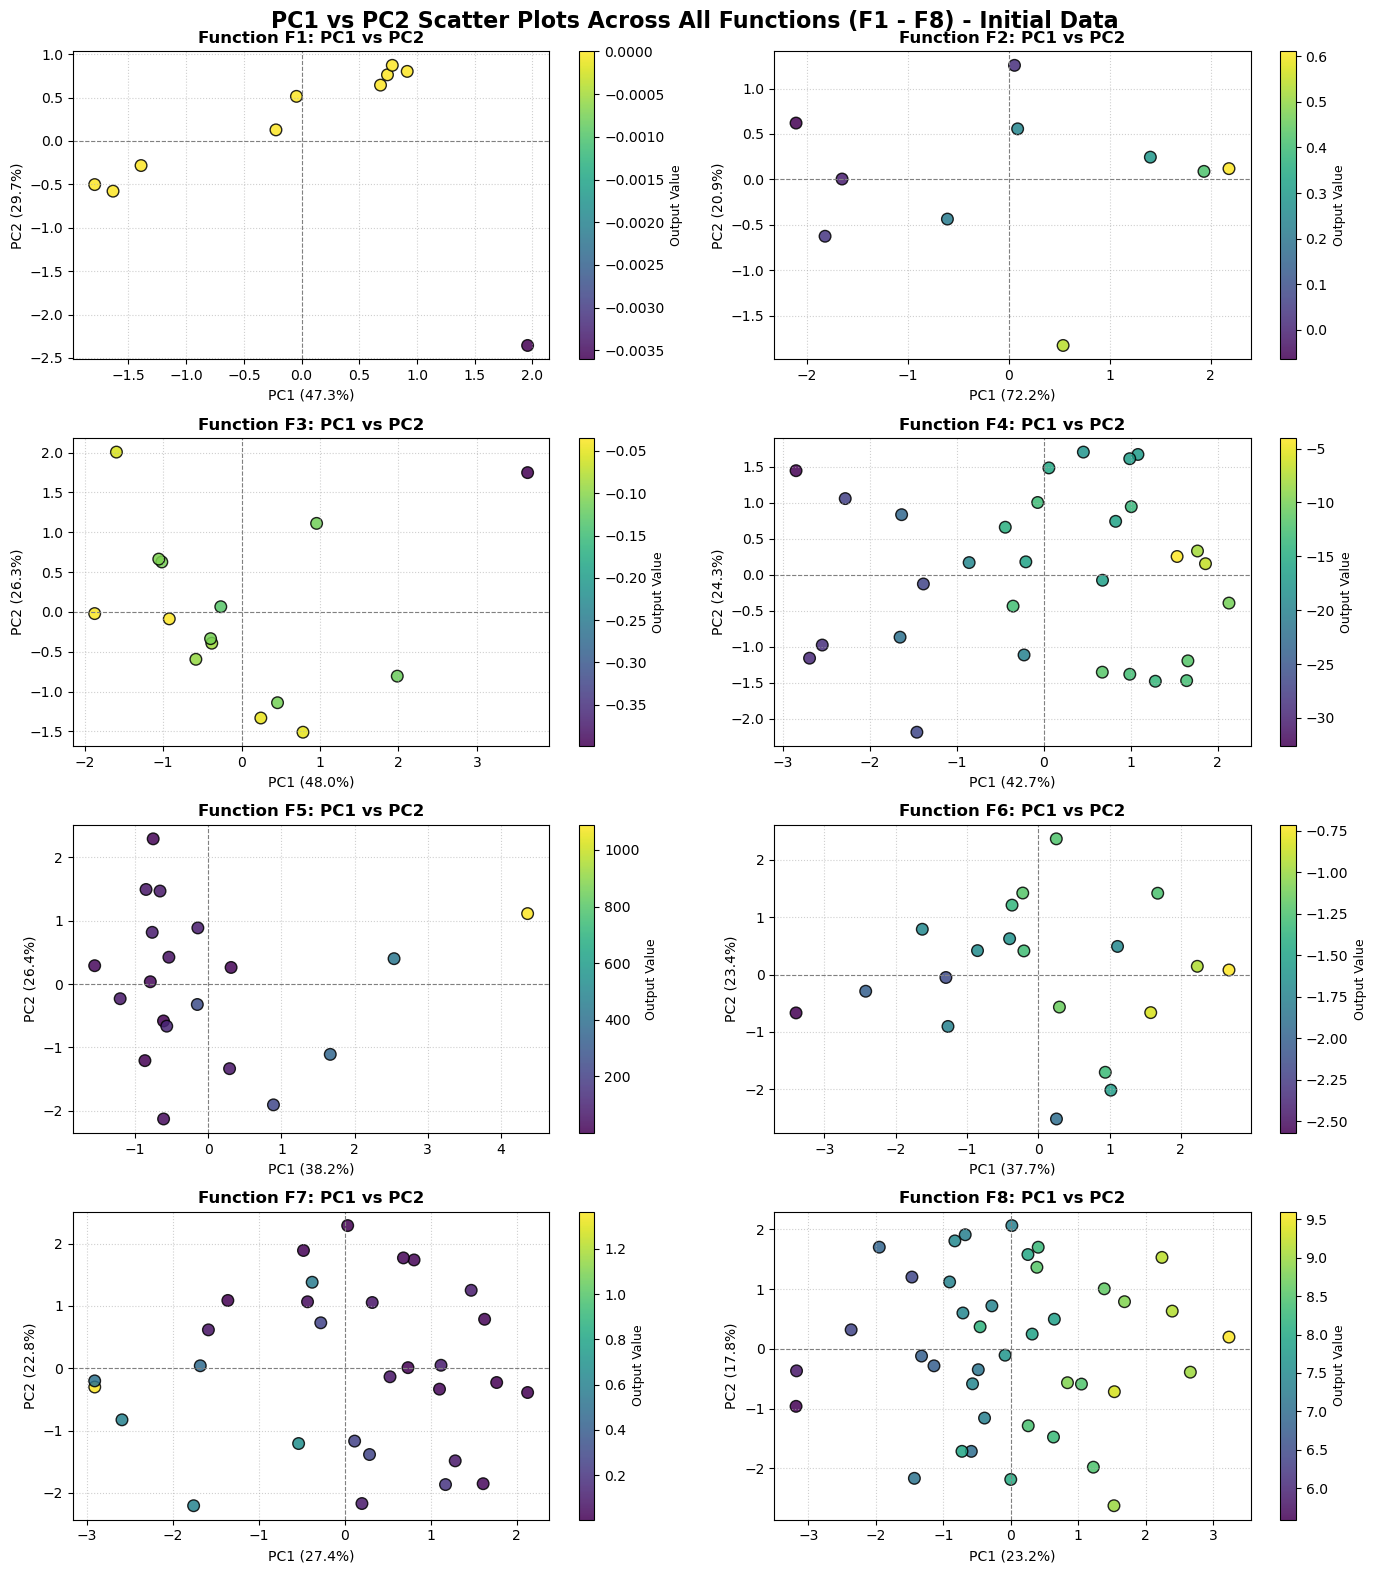

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

xls = pd.ExcelFile(filepath)

# Let's inspect each function's PCA projections
fig1, axes1 = plt.subplots(4, 2, figsize=(14, 16))
axes1 = axes1.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(filepath, sheet_name=sheet)
    
    # Standardize data across all columns
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    
    pca = PCA(n_components=min(df.shape[1], 3))
    pca_coords = pca.fit_transform(df_scaled)
    
    ax = axes1[idx]
    scatter = ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c=df['Output'], cmap='viridis', s=70, edgecolor='k', alpha=0.85)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Output Value', fontsize=9)
    
    ax.set_title(f'Function {sheet}: PC1 vs PC2', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('PC1 vs PC2 Scatter Plots Across All Functions (F1 - F8) - Initial Data', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
# plt.savefig('pc1_vs_pc2_all_functions.png', dpi=300, bbox_inches='tight')
plt.show()

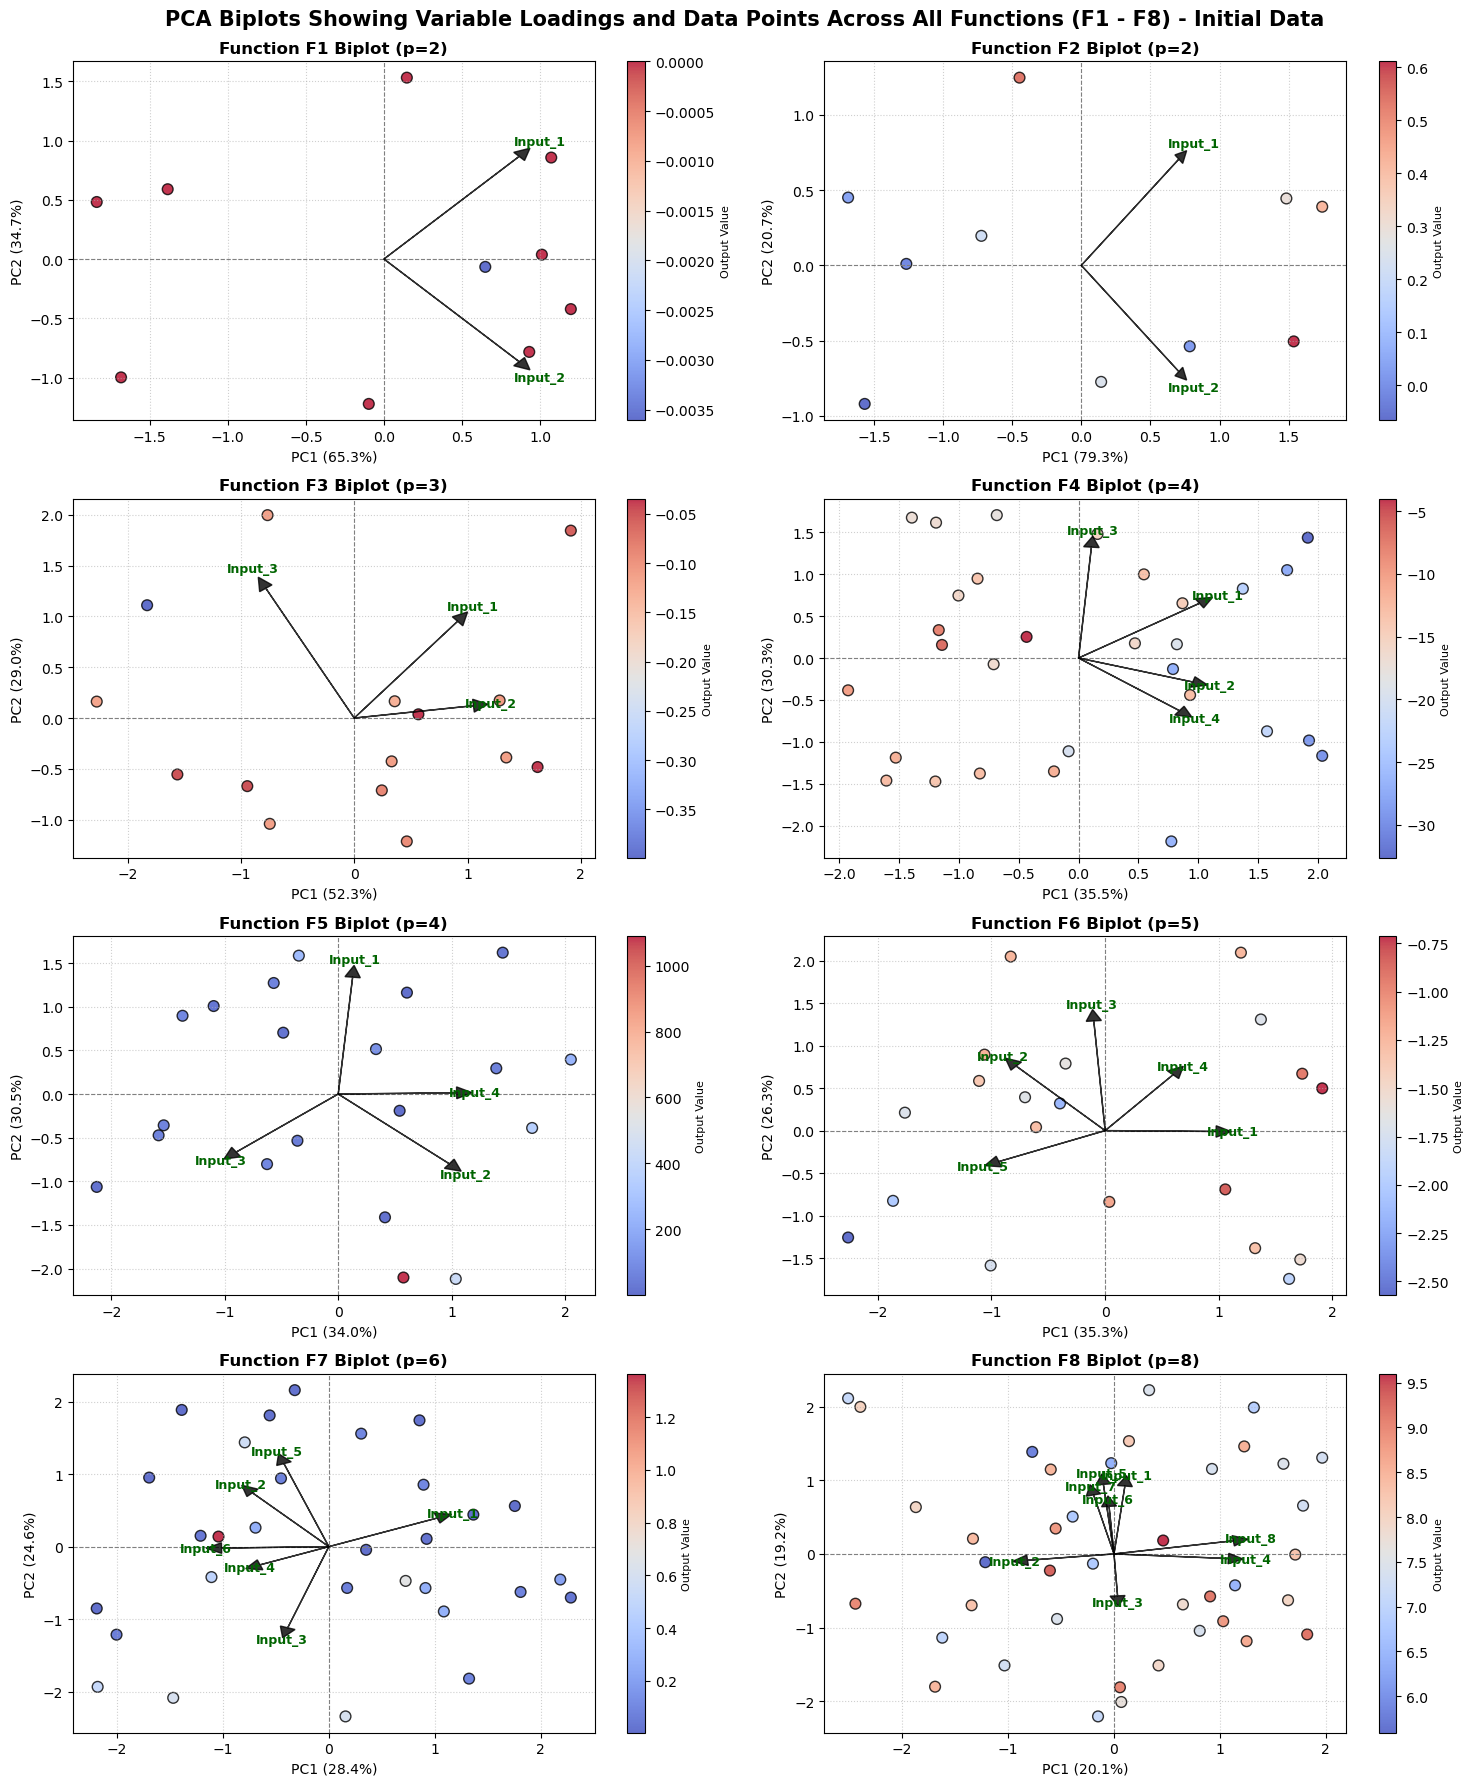

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

xls = pd.ExcelFile(filepath)

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

biplot_summary = {}

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(filepath, sheet_name=sheet)
    
    # Separate features and target if applicable, or run PCA on all features (Input_1, Input_2, ...)
    feature_cols = [c for c in df.columns if c.startswith('Input')]
    X = df[feature_cols]
    y = df['Output']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    loadings = pca.components_.T # shape (p_inputs, 2)
    
    ax = axes[idx]
    
    # Scatter plot of scores (data points)
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', s=60, edgecolor='k', alpha=0.8)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Output Value', fontsize=8)
    
    # Scale loading vectors to fit comfortably within the plot coordinates
    scalex = 1.0 / (X_pca[:, 0].max() - X_pca[:, 0].min()) if (X_pca[:, 0].max() - X_pca[:, 0].min()) != 0 else 1.0
    scaley = 1.0 / (X_pca[:, 1].max() - X_pca[:, 1].min()) if (X_pca[:, 1].max() - X_pca[:, 1].min()) != 0 else 1.0
    
    # Alternatively scale loadings by max range of PCA scores
    max_score_x = np.abs(X_pca[:, 0]).max()
    max_score_y = np.abs(X_pca[:, 1]).max()
    
    # Arrow scaling factor
    arrow_scale = min(max_score_x, max_score_y) * 0.8
    
    for i, col in enumerate(feature_cols):
        arrow_x = loadings[i, 0] * arrow_scale
        arrow_y = loadings[i, 1] * arrow_scale
        ax.arrow(0, 0, arrow_x, arrow_y, color='black', alpha=0.8, head_width=0.08*arrow_scale, head_length=0.08*arrow_scale, zorder=5)
        # Offset label slightly beyond arrow head
        ax.text(arrow_x * 1.15, arrow_y * 1.15, col, color='darkgreen', weight='bold', fontsize=9, ha='center', va='center', zorder=6)
    
    exp_var = pca.explained_variance_ratio_
    ax.set_title(f'Function {sheet} Biplot (p={len(feature_cols)})', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('PCA Biplots Showing Variable Loadings and Data Points Across All Functions (F1 - F8) - Initial Data', 
             fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
# plt.savefig('pca_biplots_all_functions.png', dpi=300, bbox_inches='tight')
plt.show()

# PCA Feature Loadings (Eigenvectors) Heatmaps Across Functions (F1 - F8) 

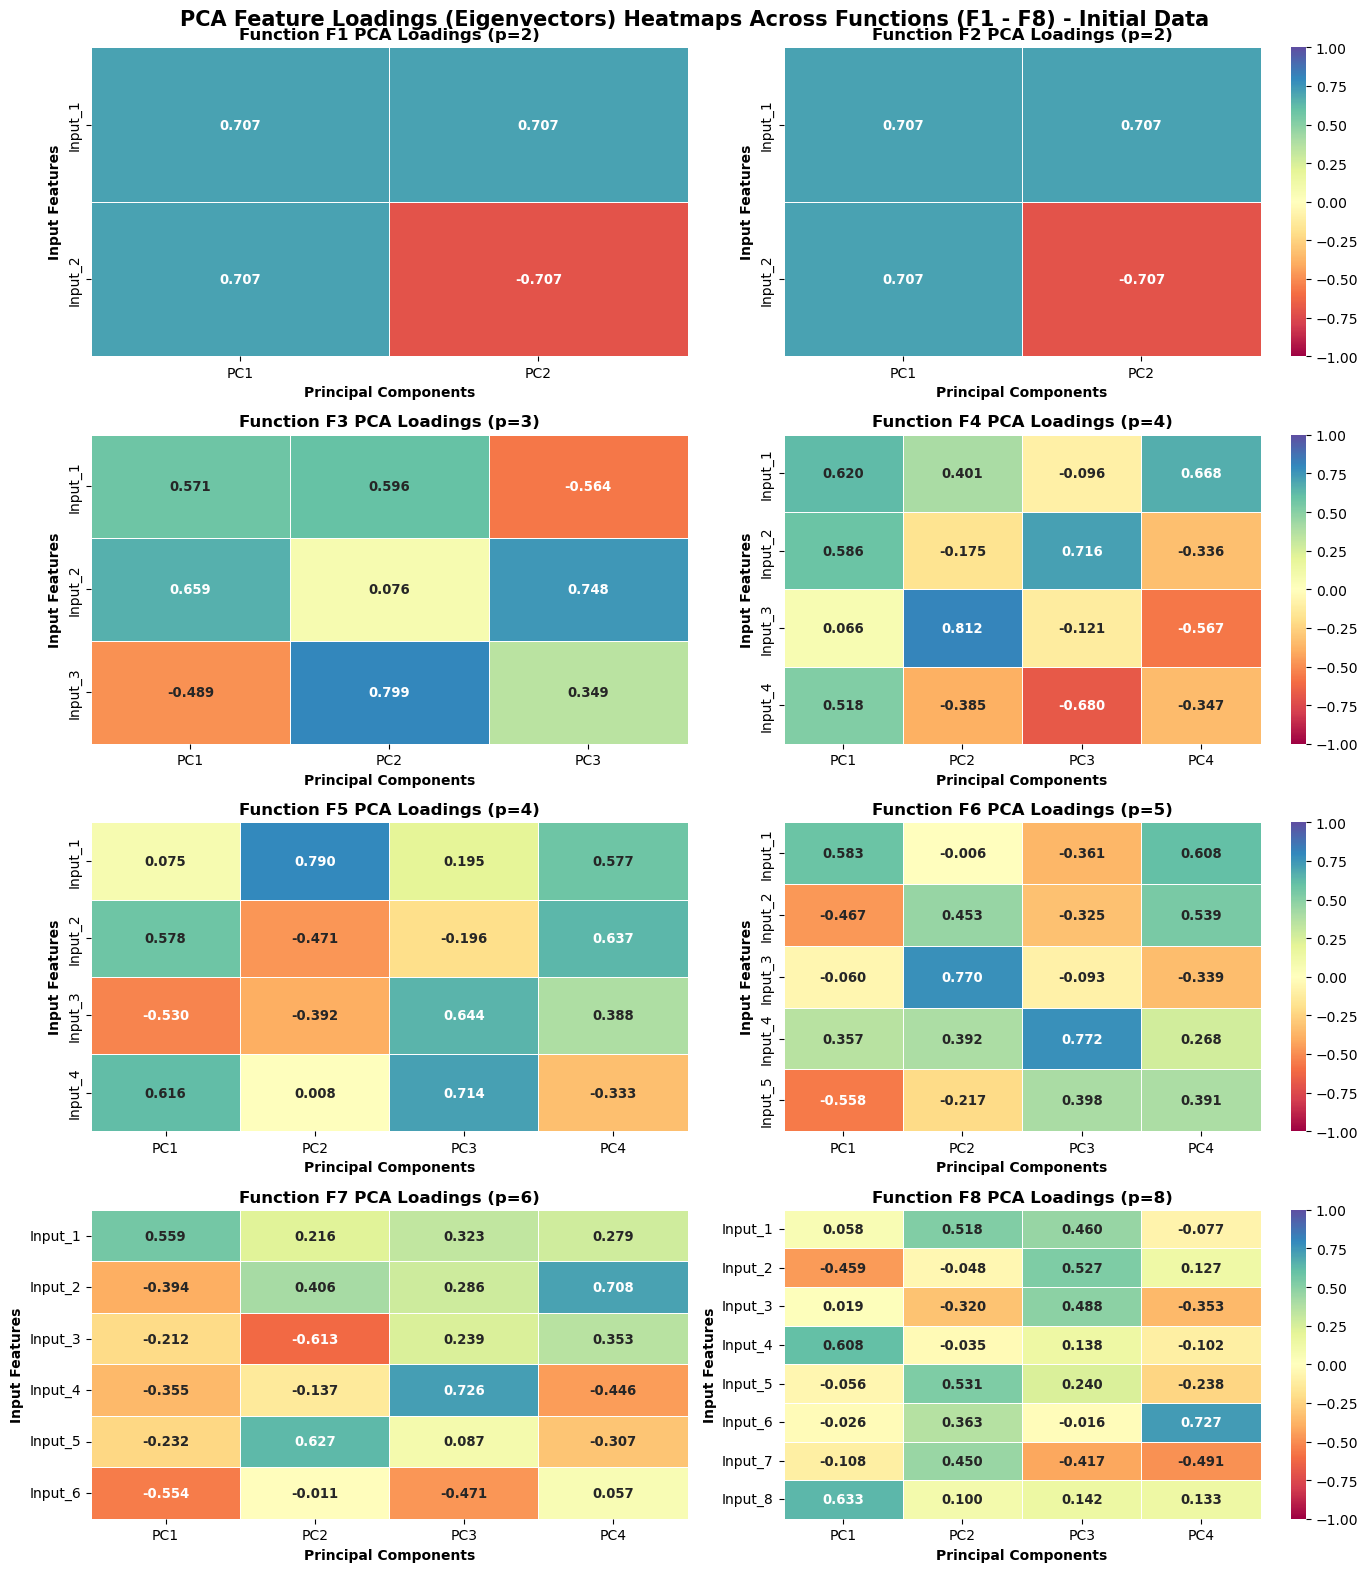

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
xls = pd.ExcelFile(filepath)

# 4x2 subplot layout
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(filepath, sheet_name=sheet)
    feature_cols = [c for c in df.columns if c.startswith('Input')]
    X = df[feature_cols].values
    
    # 1. Standardize Features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 2. Compute PCA Loadings (up to PC4)
    n_components = min(len(feature_cols), 4)
    pca = PCA(n_components=n_components)
    pca.fit(X_scaled)
    
    # Extract Feature-to-Component Loadings
    loadings = pca.components_.T  # Shape: (n_features, n_components)
    loadings_df = pd.DataFrame(
        loadings, 
        index=feature_cols, 
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    
    # 3. Plot Seaborn Heatmap
    ax = axes[idx]
    sns.heatmap(
        loadings_df, 
        annot=True, 
        fmt='.3f', 
        cmap='Spectral', 
        vmin=-1.0, 
        vmax=1.0, 
        cbar=(idx % 2 == 1), 
        ax=ax, 
        linewidths=0.5, 
        annot_kws={"size": 9.5, "weight": "bold"}
    )
    
    ax.set_title(f'Function {sheet} PCA Loadings (p={len(feature_cols)})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Input Features', fontweight='bold')
    ax.set_xlabel('Principal Components', fontweight='bold')

plt.suptitle('PCA Feature Loadings (Eigenvectors) Heatmaps Across Functions (F1 - F8) - Initial Data', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
# plt.savefig('pca_feature_loadings_heatmaps_all.png', dpi=300, bbox_inches='tight')
plt.show()

# Gaussian Process Regression (RBF Kernel) Fits Across Functions (F1 - F8)

Total warnings caught: 3
The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.


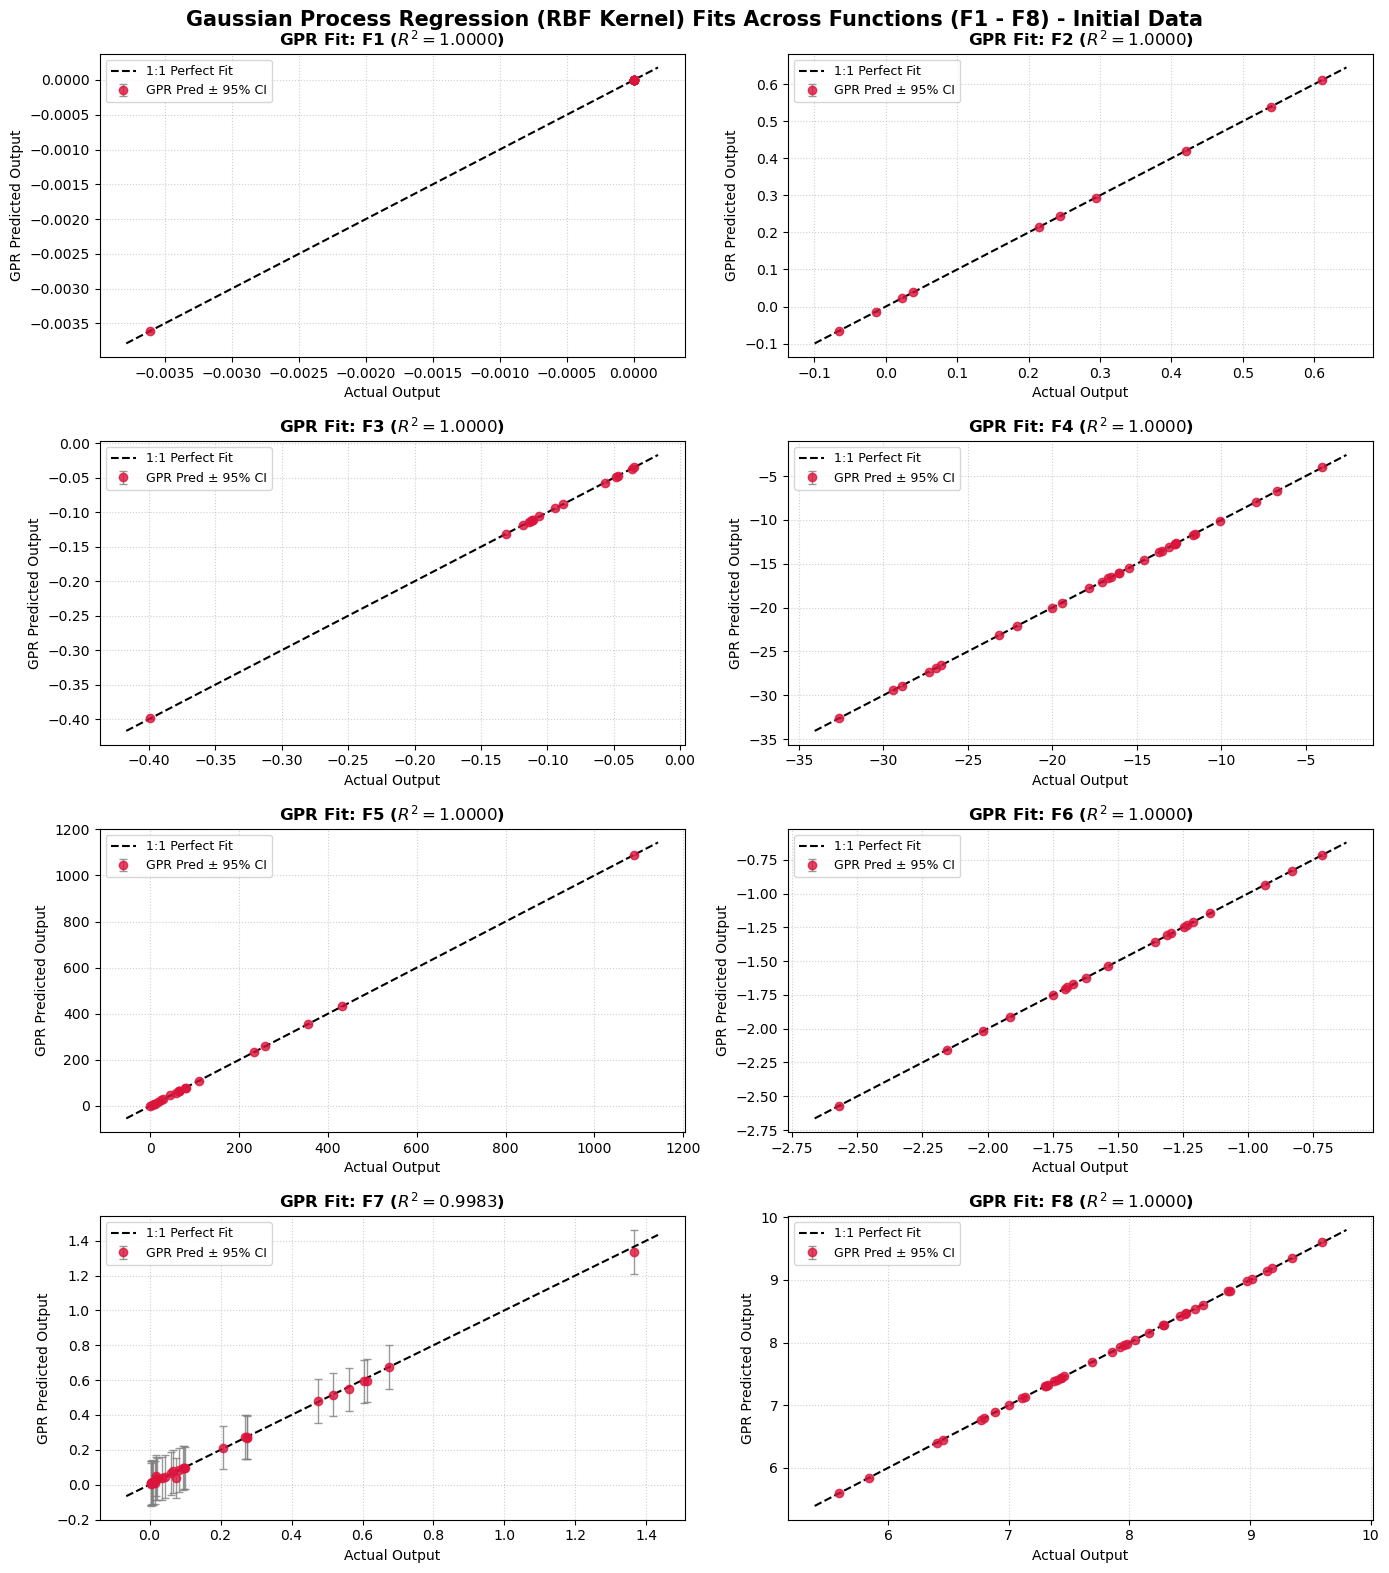

In [5]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.exceptions import ConvergenceWarning

xls = pd.ExcelFile(filepath)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

gpr_results = []

# Test catching warnings to verify zero warnings are emitted
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    
    for idx, sheet in enumerate(xls.sheet_names):
        df = pd.read_excel(filepath, sheet_name=sheet)
        feature_cols = [c for c in df.columns if c.startswith('Input')]
        X = df[feature_cols].values
        y = df['Output'].values
        
        # Standardize Features (X) & Target (y)
        scaler_X = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        
        scaler_y = StandardScaler()
        y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
        
        # Anisotropic RBF Kernel with expanded bounds (1e-5 to 1e5) for length_scale
        kernel = (
            C(1.0, (1e-3, 1e3)) * 
            RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-5, 1e5)) + 
            WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-12, 1e1))
        )
        
        # Train GPR Model
        gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
        gpr.fit(X_scaled, y_scaled)
        
        # Predict and inverse-transform
        y_pred_scaled, y_std_scaled = gpr.predict(X_scaled, return_std=True)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        y_std = y_std_scaled * scaler_y.scale_[0]
        
        # Metrics Calculation
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)
        
        gpr_results.append({
            'Function': sheet,
            'Samples (n)': len(df),
            'Features (p)': len(feature_cols),
            'R2 Score': r2,
            'RMSE': rmse,
            'MAE': mae
        })
        
        # Plotting
        ax = axes[idx]
        ax.errorbar(
            y, y_pred, yerr=1.96 * y_std, fmt='o', color='crimson', 
            ecolor='gray', elinewidth=1, capsize=3, alpha=0.8, label='GPR Pred ± 95% CI'
        )
        
        min_val, max_val = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
        margin = (max_val - min_val) * 0.05 if max_val != min_val else 0.1
        ax.plot([min_val - margin, max_val + margin], [min_val - margin, max_val + margin], 'k--', label='1:1 Perfect Fit')
        
        ax.set_title(f'GPR Fit: {sheet} ($R^2 = {r2:.4f}$)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Actual Output')
        ax.set_ylabel('GPR Predicted Output')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(fontsize=9)

    print(f"Total warnings caught: {len(w)}")
    for warning in w:
        print(warning.message)

plt.suptitle('Gaussian Process Regression (RBF Kernel) Fits Across Functions (F1 - F8) - Initial Data', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
# plt.savefig('gpr_rbf_fits_expanded_bounds.png', dpi=300, bbox_inches='tight')

# GPR RBF Length-Scale vs. PCA PC1 Loadings (F1 - F8)

### Comparison

1. **Supervised (GPR) vs. Unsupervised (PCA) Objectives**

   * **GPR Length-Scale ($\ell_i$):** An inverse measure of feature importance with respect to predicting $y$. A smaller $\ell_i$ indicates high function sensitivity to $Input_i$, whereas $\ell_i \to 1000$ indicates that the input is effectively inactive or irrelevant to the output.
   * **PCA PC1 Loading ($w_{i,1}$):** Measures the direction of maximum variance purely within the input space $X$, without considering the target output $y$.

2. **Divergence in Feature Selection**

   * In functions such as **F1, F2, and F5**, PCA assigns high PC1 loading magnitudes ($|w_{i,1}| \geq 0.57$) to features that GPR identifies as irrelevant ($\ell_i \to 1000$).
   * This demonstrates why **unsupervised variance reduction (PCA) cannot replace supervised feature screening (GPR/ARD)** when constructing predictive surrogate models.


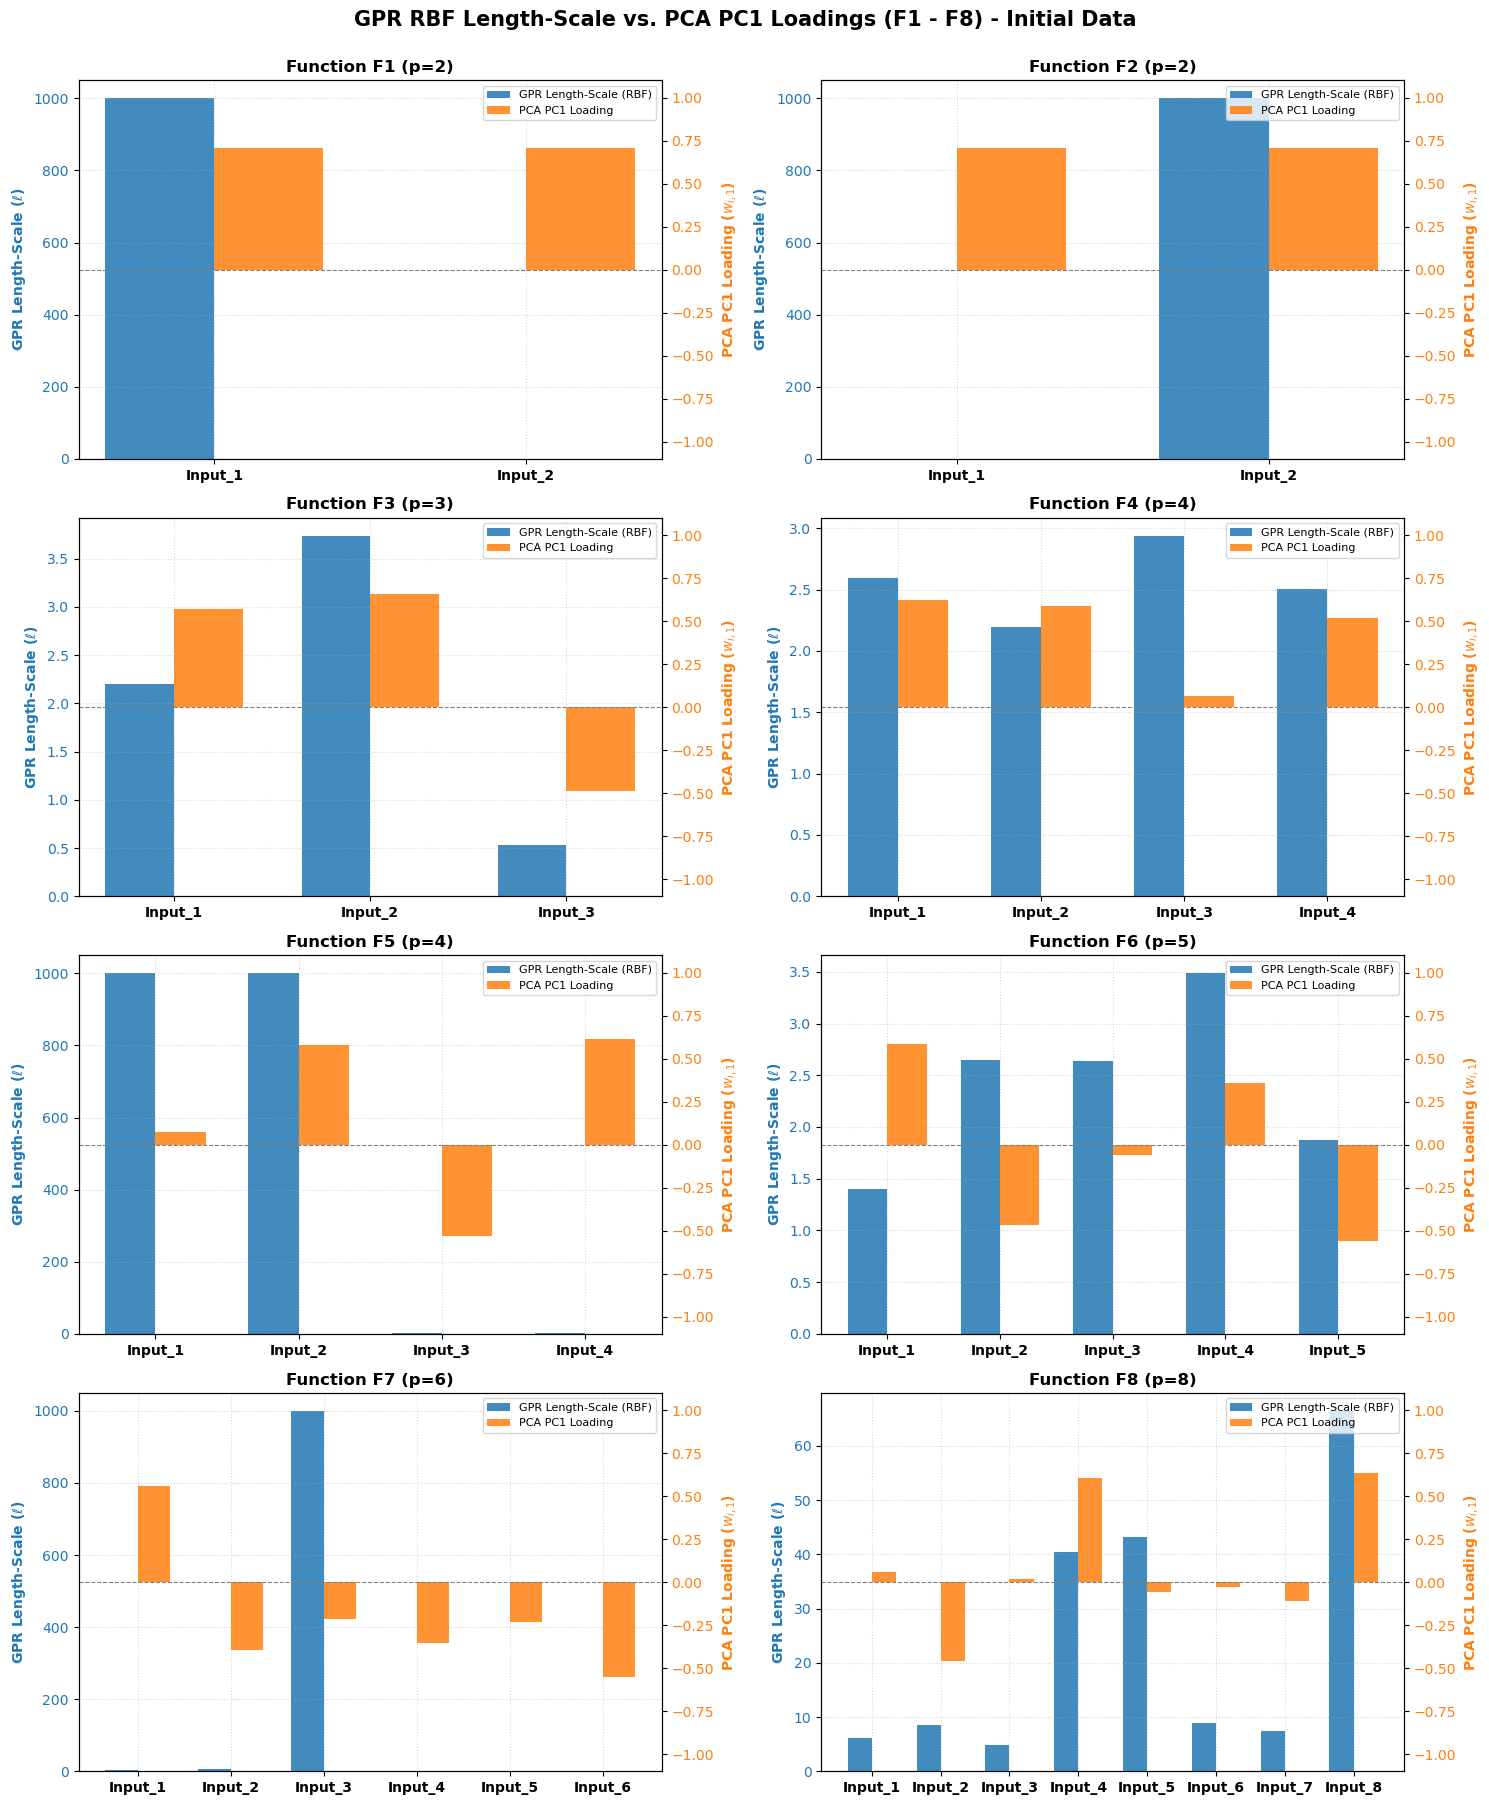

In [6]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

# Suppress scikit-learn boundary warnings for clean execution
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Load dataset
xls = pd.ExcelFile(filepath)

# 4x2 subplot grid layout
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(filepath, sheet_name=sheet)
    feature_cols = [c for c in df.columns if c.startswith('Input')]
    X = df[feature_cols].values
    y = df['Output'].values
    
    # 1. Standardize Features & Target
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
    
    # 2. Fit GPR with Anisotropic RBF Kernel
    kernel = (
        C(1.0, (1e-3, 1e3)) * 
        RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e3)) + 
        WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-12, 1e1))
    )
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X_scaled, y_scaled)
    length_scales = gpr.kernel_.k1.k2.length_scale
    
    # 3. Fit PCA
    pca = PCA(n_components=min(len(feature_cols), 4))
    pca.fit(X_scaled)
    pc1_loadings = pca.components_[0]
    
    # 4. Side-by-Side Dual-Axis Bar Chart
    ax1 = axes[idx]
    x_indices = np.arange(len(feature_cols))
    width = 0.35
    
    # Left Axis: GPR Length Scales
    color1 = 'tab:blue'
    ax1.bar(x_indices - width/2, length_scales, width, label='GPR Length-Scale (RBF)', color=color1, alpha=0.85)
    ax1.set_ylabel('GPR Length-Scale ($\ell$)', color=color1, fontweight='bold', fontsize=10)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Right Axis: PCA PC1 Loadings
    ax2 = ax1.twinx()
    color2 = 'tab:orange'
    ax2.bar(x_indices + width/2, pc1_loadings, width, label='PCA PC1 Loading', color=color2, alpha=0.85)
    ax2.set_ylabel('PCA PC1 Loading ($w_{i,1}$)', color=color2, fontweight='bold', fontsize=10)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(-1.1, 1.1)
    ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    
    # Formatting
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(feature_cols, rotation=0, fontweight='bold')
    ax1.set_title(f'Function {sheet} (p={len(feature_cols)})', fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # Combined Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

plt.suptitle('GPR RBF Length-Scale vs. PCA PC1 Loadings (F1 - F8) - Initial Data', fontsize=15, fontweight='bold', y=1)
plt.tight_layout()
# plt.savefig('gpr_vs_pca_side_by_side.png', dpi=300, bbox_inches='tight')
plt.show()